In [14]:
# Import all libraries and dependencies
import pandas as pd

In [15]:
import pandas as pd

# Load the CSV
df = pd.read_csv("BankChurners.csv")

# Drop the 'CLIENTNUM' column
df.drop(columns=['CLIENTNUM'], inplace=True)

# Select numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Print unique values for each categorical column
for col in categorical_cols:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 50)

Unique values in 'Attrition_Flag':
['Existing Customer' 'Attrited Customer']
--------------------------------------------------
Unique values in 'Gender':
['M' 'F']
--------------------------------------------------
Unique values in 'Education_Level':
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
--------------------------------------------------
Unique values in 'Marital_Status':
['Married' 'Single' 'Unknown' 'Divorced']
--------------------------------------------------
Unique values in 'Income_Category':
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
--------------------------------------------------
Unique values in 'Card_Category':
['Blue' 'Gold' 'Silver' 'Platinum']
--------------------------------------------------


In [19]:
cleaned_df = df.copy()
# Drop NA
cleaned_df.dropna()
# Drop duplicates
cleaned_df.drop_duplicates(inplace=True)

# IQR Filtering
for col in numeric_cols:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]

# Step 4: Check final shape after removing outliers
print("Cleaned dataset shape:", cleaned_df.shape)

# Optional: Save cleaned data
cleaned_df.to_csv("IQRcleaned_dataset.csv", index=False)
cleaned_df.head

Cleaned dataset shape: (5181, 22)


<bound method NDFrame.head of          Attrition_Flag  Customer_Age Gender  Dependent_count Education_Level  \
10    Existing Customer            42      M                5      Uneducated   
14    Existing Customer            57      F                2        Graduate   
19    Existing Customer            45      F                2        Graduate   
23    Existing Customer            47      F                4         Unknown   
24    Existing Customer            54      M                2         Unknown   
...                 ...           ...    ...              ...             ...   
9110  Existing Customer            60      M                1     High School   
9122  Existing Customer            45      M                2     High School   
9130  Existing Customer            47      F                4   Post-Graduate   
9133  Existing Customer            46      F                4      Uneducated   
9139  Existing Customer            55      M                4         Unknown  

In [20]:
import pandas as pd

# Load the cleaned dataset.
cleaned_df = pd.read_csv("BankChurners.csv")

# Assuming you have your list of numeric columns defined (e.g., as done before)
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns

# Create a copy of the original DataFrame before IQR filtering.
original_df = cleaned_df.copy()

# Dictionary to record the first column that causes each row to fail the IQR filter.
drop_causes = {}

# Start with the full dataset. We'll update this DataFrame as we apply each column's filter.
df_iter = original_df.copy()

for col in numeric_cols:
    Q1 = df_iter[col].quantile(0.25)
    Q3 = df_iter[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create mask for rows that pass the IQR filter for current column.
    mask = (df_iter[col] >= lower_bound) & (df_iter[col] <= upper_bound)

    # Identify rows that fail this column's IQR filter.
    dropped_rows = df_iter.index[~mask]

    # Record the column for each dropped row if it hasn't been recorded before.
    for idx in dropped_rows:
        if idx not in drop_causes:
            drop_causes[idx] = col

    # Update df_iter to only include rows that pass the filter for this column.
    df_iter = df_iter[mask]

# df_iter now contains the rows remaining after all IQR filters.
print("Shape before IQR filtering:", original_df.shape)
print("Shape after IQR filtering:", df_iter.shape)

# Create a DataFrame from drop_causes for further analysis.
drop_causes_df = pd.DataFrame(list(drop_causes.items()), columns=['Row_Index', 'Column_Causing_Drop'])
print("\nRows dropped and the column that triggered the deletion:")
print(drop_causes_df)

# Optional: Focus on Attrited Customers – for example, see which Attrited Customer rows were dropped and why.
# Note: Adjust the 'Attrition_Flag' column name as needed (e.g., if it's encoded differently).
attrited_dropped = original_df.loc[drop_causes_df['Row_Index']]
attrited_dropped = attrited_dropped[attrited_dropped['Attrition_Flag'] == 'Attrited Customer']
print("\nAttrited Customer rows dropped (with their indices):")
print(attrited_dropped[['Attrition_Flag']])


Shape before IQR filtering: (10127, 23)
Shape after IQR filtering: (5181, 23)

Rows dropped and the column that triggered the deletion:
      Row_Index                                Column_Causing_Drop
0           251                                       Customer_Age
1           254                                       Customer_Age
2            11                                     Months_on_book
3            18                                     Months_on_book
4            27                                     Months_on_book
...         ...                                                ...
4941       5567  Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...
4942       5572  Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...
4943       5577  Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...
4944       5635  Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...
4945       6869  Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...

[4946 rows x 2 columns]

Attrited Customer rows dropped (wi

In [21]:
# Count the number of times each column triggered the drop
drop_count = drop_causes_df['Column_Causing_Drop'].value_counts()

print("Count of rows dropped per column:")
print(drop_count)


Count of rows dropped per column:
Column_Causing_Drop
Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1    1091
Credit_Limit                                                                                                                           859
Contacts_Count_12_mon                                                                                                                  584
Total_Trans_Amt                                                                                                                        575
Avg_Open_To_Buy                                                                                                                        467
Months_on_book                                                                                                                         385
Months_Inactive_12_mon                                                                                          

C:\Users\Gan Qing Rong\AppData\Local\Temp\ipykernel_3952\762153187.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


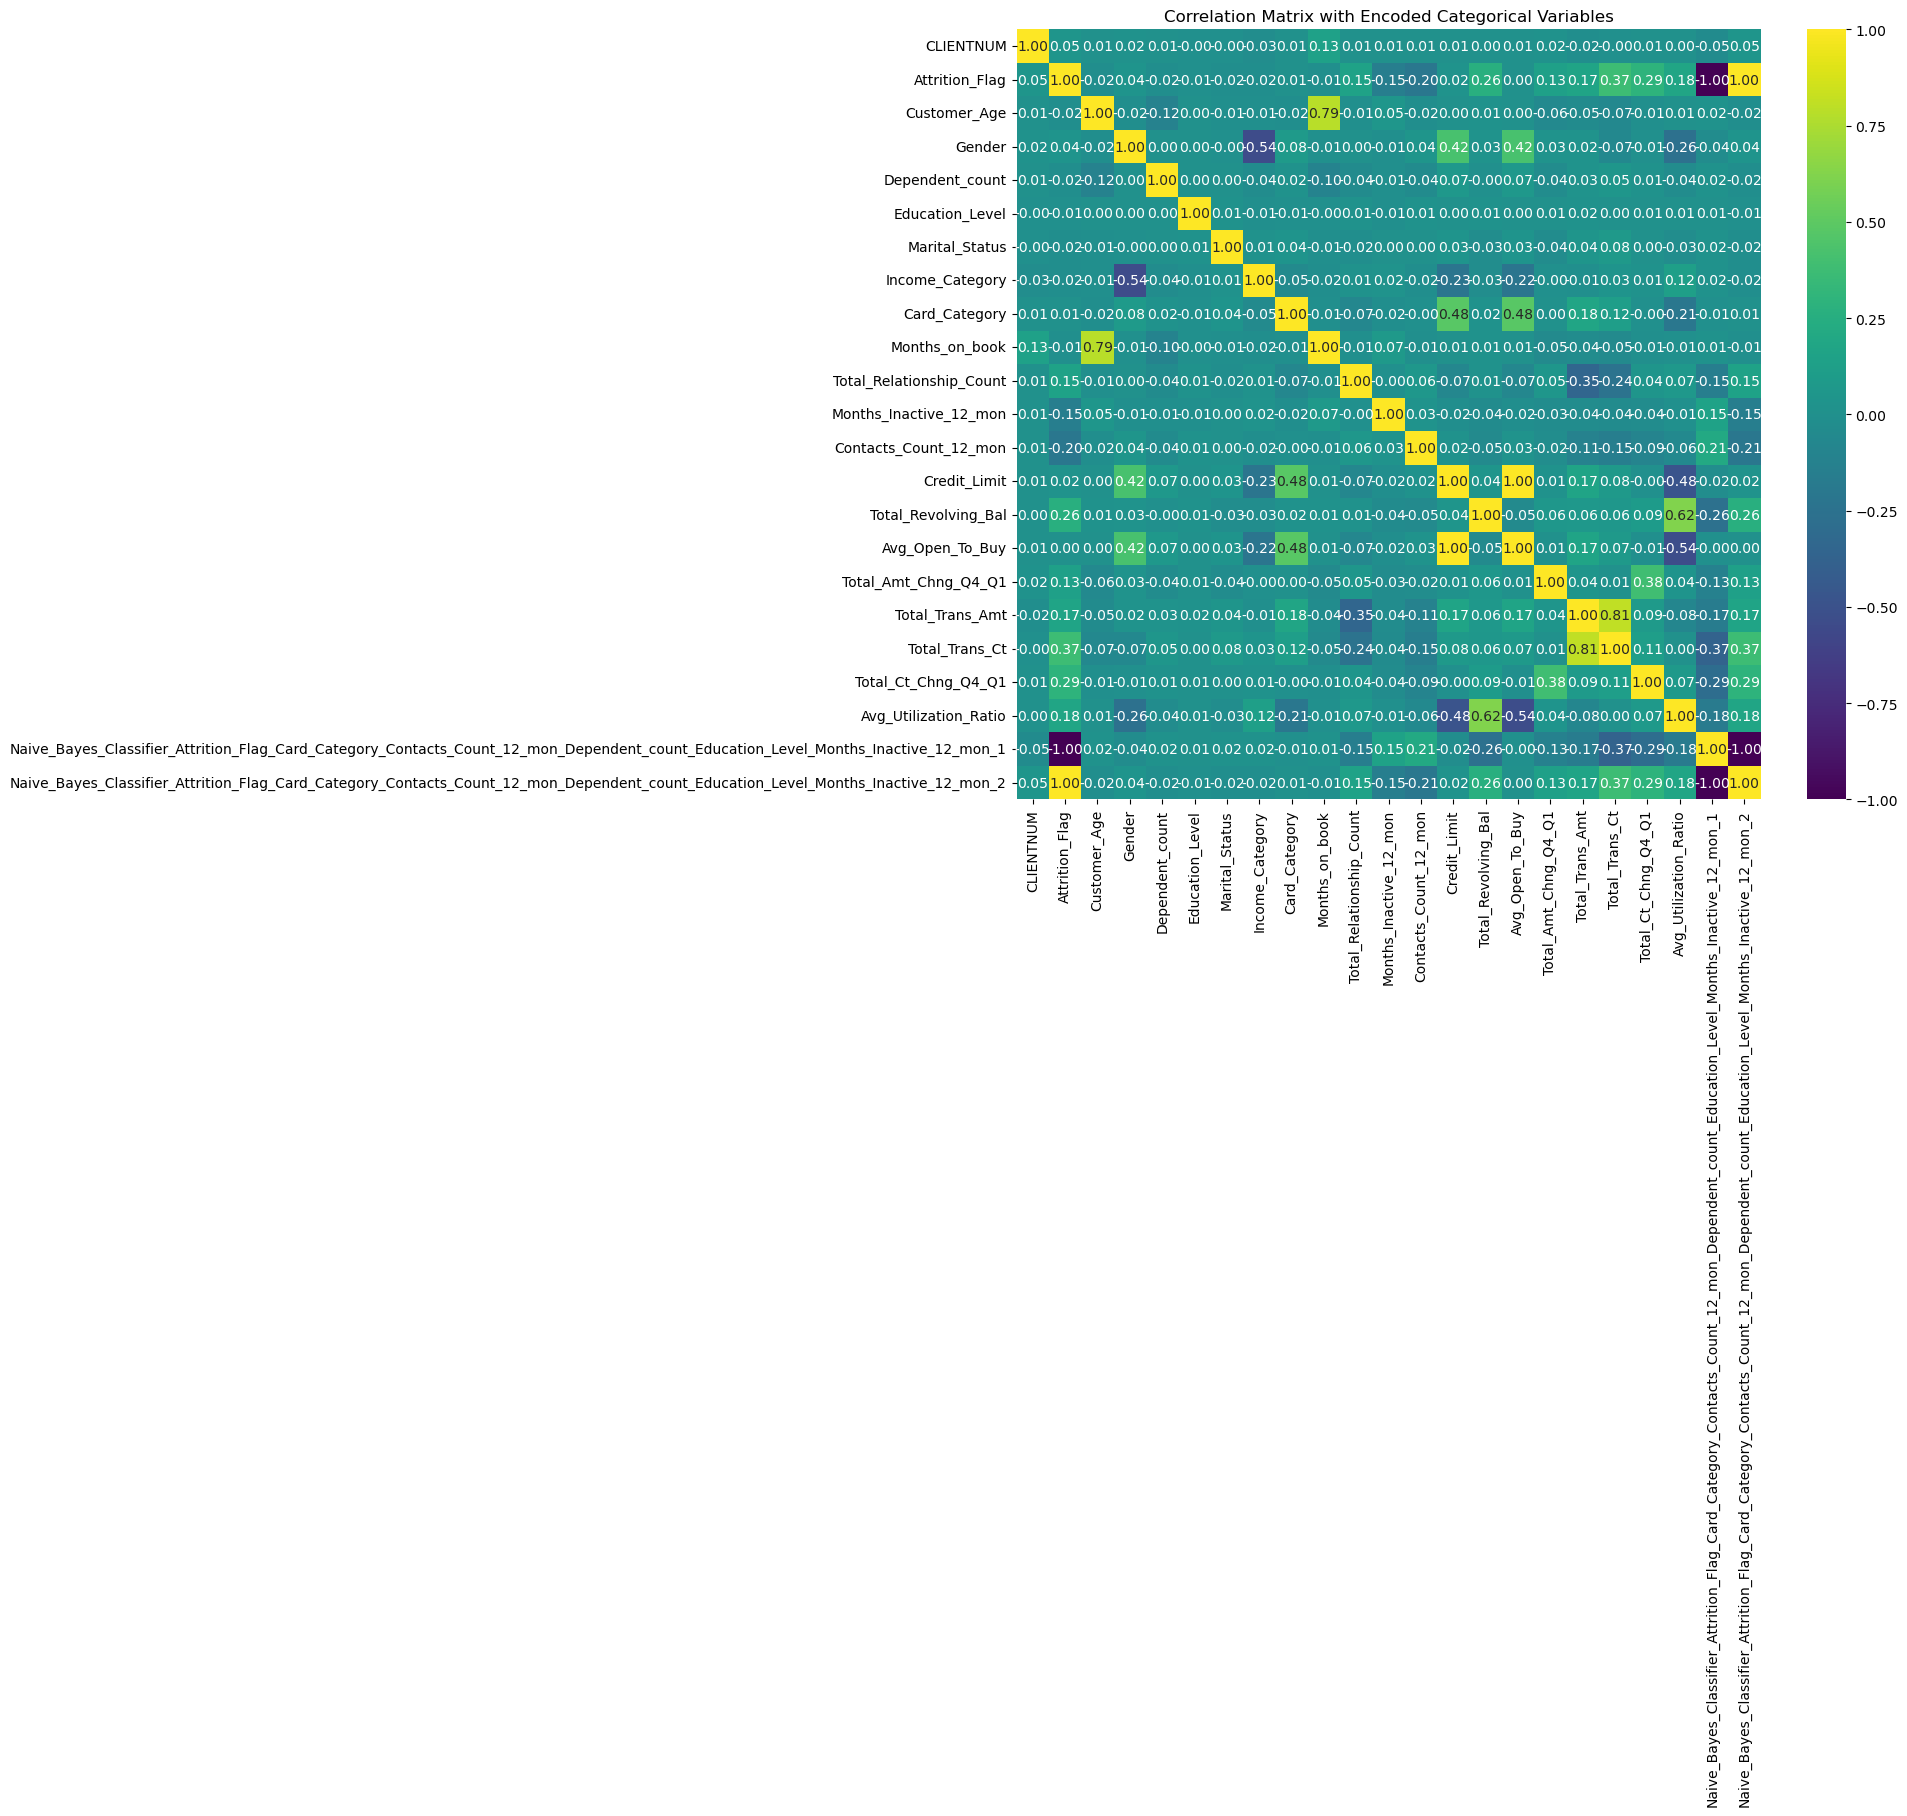

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load the cleaned dataset.
df = pd.read_csv("BankChurners.csv")

# List of categorical columns as provided.
categorical_cols = [
    'Attrition_Flag', 
    'Gender', 
    'Education_Level', 
    'Marital_Status', 
    'Income_Category', 
    'Card_Category'
]

# Create a copy of the DataFrame for encoding.
df_encoded = df.copy()

# Apply label encoding to each categorical column.
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Compute the correlation matrix for the entire DataFrame.
corr_matrix = df_encoded.corr()

# Create a heatmap for the correlation matrix.
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='viridis', annot=True, fmt=".2f")
plt.title('Correlation Matrix with Encoded Categorical Variables')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [22]:
import pandas as pd
from sklearn.feature_selection import f_classif

# Assume df_encoded is your DataFrame with all features encoded, including "Attrition_Flag".
# Define the target variable.
target = 'Attrition_Flag'

# Create X containing all features except the target variable,
# and y containing the target.
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Compute F-scores and p-values using the ANOVA F-test.
F_values, p_values = f_classif(X, y)

# Create a DataFrame to display the F-scores and p-values along with the feature names.
f_scores_df = pd.DataFrame({
    'Feature': X.columns,
    'F_score': F_values,
    'p_value': p_values
}).sort_values(by='F_score', ascending=False)

print("F-scores against Attrition_Flag:")
print(f_scores_df)


F-scores against Attrition_Flag:
                                              Feature       F_score  \
20  Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...  4.518525e+08   
21  Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...  4.518463e+08   
17                                     Total_Trans_Ct  1.620122e+03   
18                                Total_Ct_Chng_Q4_Q1  9.300784e+02   
13                                Total_Revolving_Bal  7.527024e+02   
11                              Contacts_Count_12_mon  4.418681e+02   
19                              Avg_Utilization_Ratio  3.328768e+02   
16                                    Total_Trans_Amt  2.962277e+02   
10                             Months_Inactive_12_mon  2.409104e+02   
9                            Total_Relationship_Count  2.330729e+02   
15                               Total_Amt_Chng_Q4_Q1  1.769616e+02   
0                                           CLIENTNUM  2.187446e+01   
2                                           

In [23]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Assume df_encoded is your DataFrame with features encoded, including "Attrition_Flag".

# Define the target variable and feature set.
target = 'Attrition_Flag'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Compute the mutual information for each feature with respect to the target.
mi_values = mutual_info_classif(X, y, random_state=42)

# Create a DataFrame to display the mutual information values along with the feature names.
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi_values
}).sort_values(by='Mutual_Information', ascending=False)

print("Mutual Information of each feature with Attrition_Flag:")
print(mi_df)


Mutual Information of each feature with Attrition_Flag:
                                              Feature  Mutual_Information
21  Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...            0.440811
20  Naive_Bayes_Classifier_Attrition_Flag_Card_Cat...            0.440811
16                                    Total_Trans_Amt            0.156990
17                                     Total_Trans_Ct            0.112151
18                                Total_Ct_Chng_Q4_Q1            0.094922
13                                Total_Revolving_Bal            0.083706
19                              Avg_Utilization_Ratio            0.050353
15                               Total_Amt_Chng_Q4_Q1            0.030872
11                              Contacts_Count_12_mon            0.029242
10                             Months_Inactive_12_mon            0.023402
14                                    Avg_Open_To_Buy            0.020839
9                            Total_Relationship_Count   